# Objective Analysis of Meteorological Fields 

## Gandin (1963)

Este notebook apresenta dois exemplos das ideias apresentadas por Gandin em seu livro de 1963, intitulado _Objective Analysis of Meteorological Fields_. Este foi o primeiro trabalho a formular o problema de análise objetiva multivariado utilizando estatística. O objetivo era viabilizar a implementação do método nos computadores da época. 

Algumas das suposições utilizadas por Gandin:

* Isotropia e homogeneidade das correlações;
* Funções de correlação com decaimento exponencial simples;
* Raio de influência - limita o número de observações consideradas ao redor de cada ponto de grade (escala de correlação).

## Exemplo 1D

### Definição do modelo

Considere um modelo matemático simples, a função seno com a adição de um ruído normalmente distribuído:

$$
f(x) = \sin(x) + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma^2), \quad -\pi \le x \le \pi
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.colors as colors

In [2]:
x = np.arange(-np.pi, np.pi, 0.01)
xb_seno = np.sin(x)

sigma = 0.5  # desvio-padrão do ruído
ruido = np.random.randn(*x.shape) * sigma 

xb = xb_seno + ruido

### Determinação das observações

In [3]:
# Posições
obs_x = np.array([-2.2, -2.1, -2.0, -1.8, 0.9, 1, 2, 3])

# Valores medidos
obs_val = np.array([-2.2, -1.8, 0.9, 0, 1, 2, 3, 4]) 

### Determinação dos pesos

In [4]:
L=0.5
sigma_b=0.5
sigma_o=0.1

def weight_io(x_grid, obs_x, obs_val, xb, L=L, sigma_b=sigma_b, sigma_o=sigma_o):
    def cov(a, b): return sigma_b**2 * np.exp(-((a - b)**2)/(2*L**2))
    n = len(x_grid)
    p = len(obs_x)
    B_Ht = np.array([[cov(xi, xj) for xj in obs_x] for xi in x_grid])
    HBHt = np.array([[cov(xi, xj) for xi in obs_x] for xj in obs_x])
    R = np.eye(p) * sigma_o**2
    K = B_Ht @ np.linalg.inv(HBHt + R)
    Hxb = np.interp(obs_x, x_grid, xb)
    return xb + K @ (obs_val - Hxb)

In [5]:
xa = weight_io(x, obs_x, obs_val, xb)

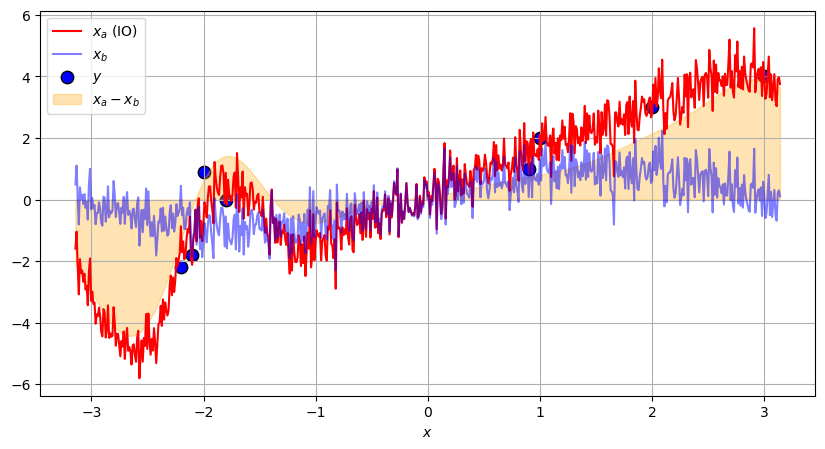

In [6]:
plt.figure(figsize=(10,5))
plt.plot(x, xa, 'r-', label='$x_a$ (IO)')
plt.plot(x, xb, 'b-', label='$x_b$', alpha=0.5)
plt.scatter(obs_x, obs_val, c='blue', s=80, edgecolor='k', label='$y$')
plt.fill_between(x, xa-xb, 0, color="orange", alpha=0.3, label="$x_{a}-x_{b}$")

plt.xlabel('$x$')
plt.legend()
plt.grid(True)
plt.show()

## Exemplo 2D

### Definição do modelo

In [7]:
nx, ny = 30, 30
x = np.linspace(0, 2*np.pi, nx)
y = np.linspace(0, 2*np.pi, ny)
X, Y = np.meshgrid(x, y)
#true_field_2d = np.sin(X) * np.cos(Y)
xb_2d = np.sin(X + 0.3) * np.cos(Y + 0.2) * 0.8

In [8]:
lon = np.linspace(-np.pi, np.pi, 10)
lat = np.linspace(-np.pi, np.pi, 10)

X, Y = np.meshgrid(lon, lat)

In [9]:
xb_seno = np.sin(X)

sigma = 0.5  # desvio-padrão do ruído
ruido = np.random.randn(*X.shape) * sigma

xb_2d = xb_seno + ruido

### Determinação das observações

In [10]:
# Posições
obs_x = np.array([-2.2, -2.1, -2.0, -1.8, 0.9, 1.0, 2.0, 3.0])  
obs_y = np.array([ -1, 0.5, -0.5, 2, -2.8, 1.0, 0.0, 0.5]) 

# Valores medidos
obs_val = np.array([-1.0, -1.5, -2.0, -1.0, 1.0, 0.0, 0.5, 0.0]) 

### Determinação dos pesos

In [11]:
L=0.5
sigma_b=0.5
sigma_o=0.1

def weight_io_2d(X, Y, obs_x, obs_y, obs_val, xb, L=L, sigma_b=sigma_b, sigma_o=sigma_o):
    obs_pos = np.vstack((obs_x, obs_y)).T
    grid_pos = np.vstack((X.ravel(), Y.ravel())).T
    def cov(p1, p2): return sigma_b**2 * np.exp(-np.sum((p1 - p2)**2)/(2*L**2))
    B = np.array([[cov(p1, p2) for p2 in obs_pos] for p1 in obs_pos])
    Hx = np.array([[cov(p1, p2) for p2 in obs_pos] for p1 in grid_pos])
    R = np.eye(len(obs_x))*sigma_o**2
    K = Hx @ np.linalg.inv(B + R)
    Hxb = np.interp(obs_x, np.linspace(0, 2*np.pi, X.shape[1]), xb.mean(axis=0))
    ana = xb.ravel() + K @ (obs_val - Hxb)
    return ana.reshape(X.shape)

In [12]:
xa = weight_io_2d(X, Y, obs_x, obs_y, obs_val, xb_2d)

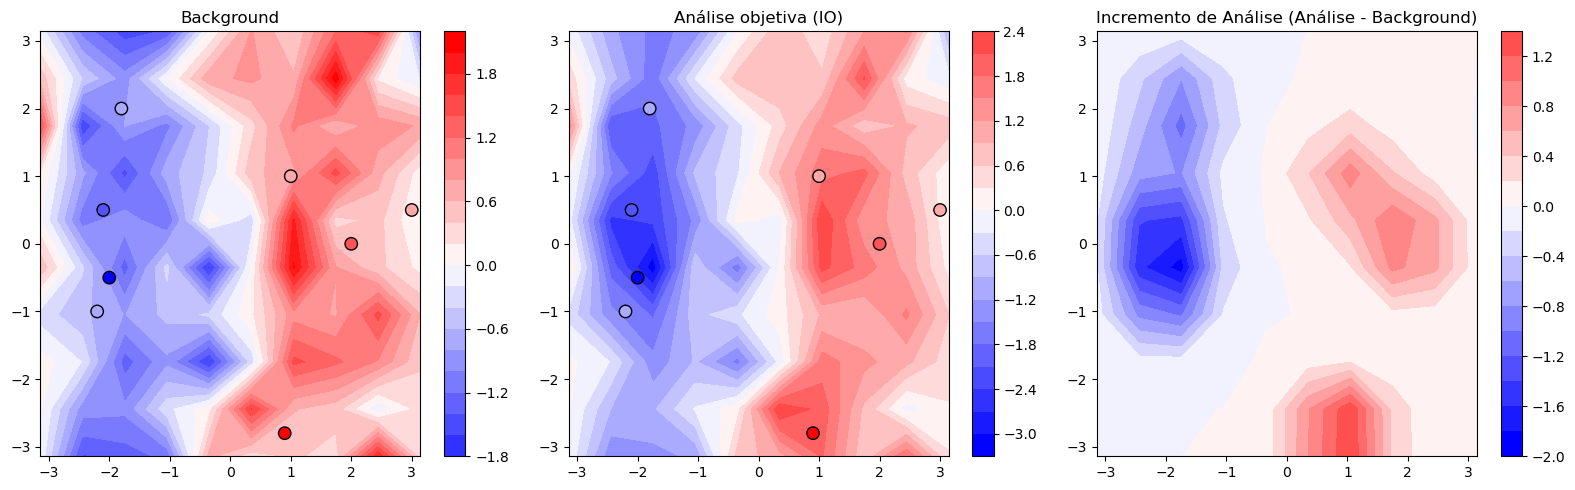

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(16,5))

vmax1 = np.max(np.abs(xb_2d))
cf0 = axs[0].contourf(X, Y, xb_2d, 20, cmap="bwr", norm=colors.TwoSlopeNorm(vmin=-vmax1, vcenter=0, vmax=vmax1))
axs[0].scatter(obs_x, obs_y, c=obs_val, edgecolor='k', cmap="bwr", s=80)
axs[0].set_title('Background')

vmax2 = np.max(np.abs(xa))
cf1 = axs[1].contourf(X, Y, xa, 20, cmap="bwr", norm=colors.TwoSlopeNorm(vmin=-vmax2, vcenter=0, vmax=vmax2))
axs[1].scatter(obs_x, obs_y, c=obs_val, edgecolor='k', cmap="bwr", s=80)
axs[1].set_title('Análise objetiva (IO)')

increment = xa - xb_2d
# limites simétricos em torno de zero
vmax3 = np.max(np.abs(increment))
cf2 = axs[2].contourf(X, Y, increment, 20, cmap="bwr", norm=colors.TwoSlopeNorm(vmin=-vmax3, vcenter=0, vmax=vmax3))
axs[2].set_title('Incremento de Análise (Análise - Background)')

for c in (cf0, cf1, cf2):
    plt.colorbar(c, ax=axs.tolist()[ [cf0,cf1,cf2].index(c) ])

plt.tight_layout()
plt.show()

## Perguntas

Para ambos os casos 1D e 2D:

1. O que acontece com a análise quando $\sigma_b = 0$ e quando $\sigma_o = 0$ - ou um número muito pequeno? Comente os resultados.
2. O que acontece com a análise quando $L$ (escala de correlação) é muito grande ou muito pequeno? Comente os resultados.
3. Como o método de Interpolação Ótima se compara com os demais métodos estudados até agora?